In [3]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt


In [5]:
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

print("Training images shape:", train_images.shape)  # (60000, 28, 28)
print("Testing images shape:", test_images.shape)    # (10000, 28, 28)
print("Training labels:", train_labels[:10])

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 4us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 45s 2us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 7s 2us/step
Training images shape: (60000, 28, 28)
Testing images shape: (10000, 28, 28)
Training labels: [9 0 0 3 0 2 7 2 5 5]


In [7]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


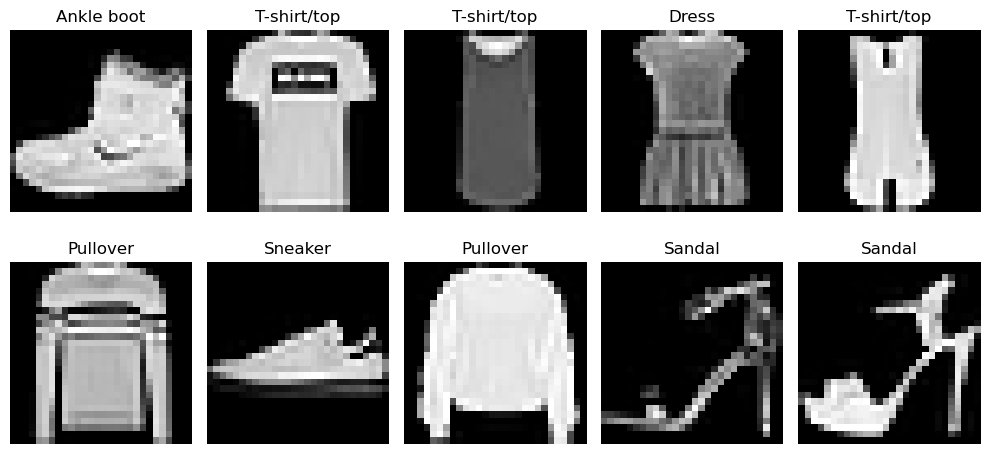

In [9]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(class_names[train_labels[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()


In [11]:
train_images = train_images / 255.0
test_images  = test_images  / 255.0

print("Pixel value range after normalization:", train_images.min(), "to", train_images.max())

Pixel value range after normalization: 0.0 to 1.0


In [13]:
model = keras.Sequential([
    # Flatten: converts 28x28 grid into flat array of 784 numbers
    keras.layers.Flatten(input_shape=(28, 28)),
    
    # First Dense hidden layer: 128 neurons, ReLU activation
    keras.layers.Dense(128, activation='relu'),
    
    # Output layer: 10 neurons (one per class), Softmax for probabilities
    keras.layers.Dense(10, activation='softmax')
])

# Display model summary
model.summary()

C:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
history = model.fit(
    train_images, train_labels,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.7710 - loss: 0.6692 - val_accuracy: 0.8501 - val_loss: 0.4296
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8587 - loss: 0.3980 - val_accuracy: 0.8640 - val_loss: 0.3769
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.8741 - loss: 0.3539 - val_accuracy: 0.8662 - val_loss: 0.3621
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.8822 - loss: 0.3214 - val_accuracy: 0.8712 - val_loss: 0.3611
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.8853 - loss: 0.3058 - val_accuracy: 0.8801 - val_loss: 0.3321
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.8950 - loss: 0.2886 - val_accuracy: 0.8843 - val_loss: 0.3251
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.8983 - loss: 0.2731 - val_accuracy: 0.8874 - val_loss: 0.3200
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.9040 - loss: 0

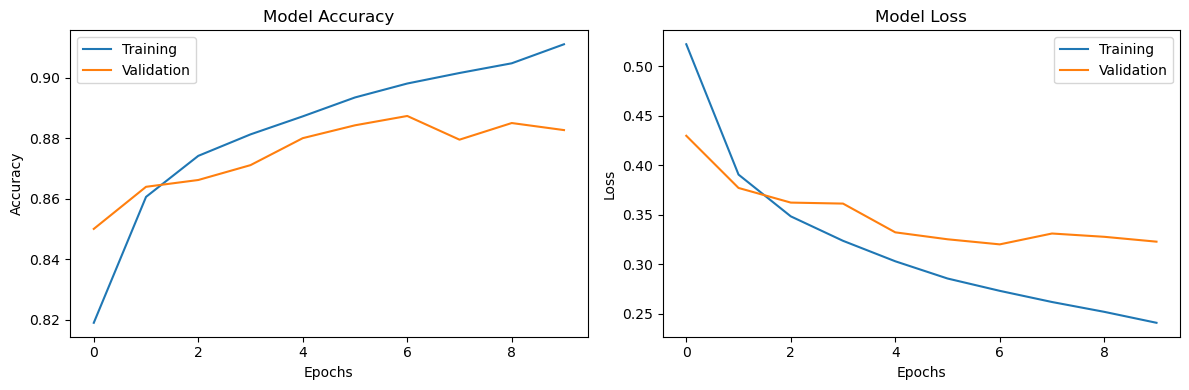

In [19]:
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Training', 'Validation'])

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training', 'Validation'])

plt.tight_layout()
plt.show()

In [21]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('Test accuracy:', test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8789 - loss: 0.3395
Test accuracy: 0.8761000037193298


In [23]:
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


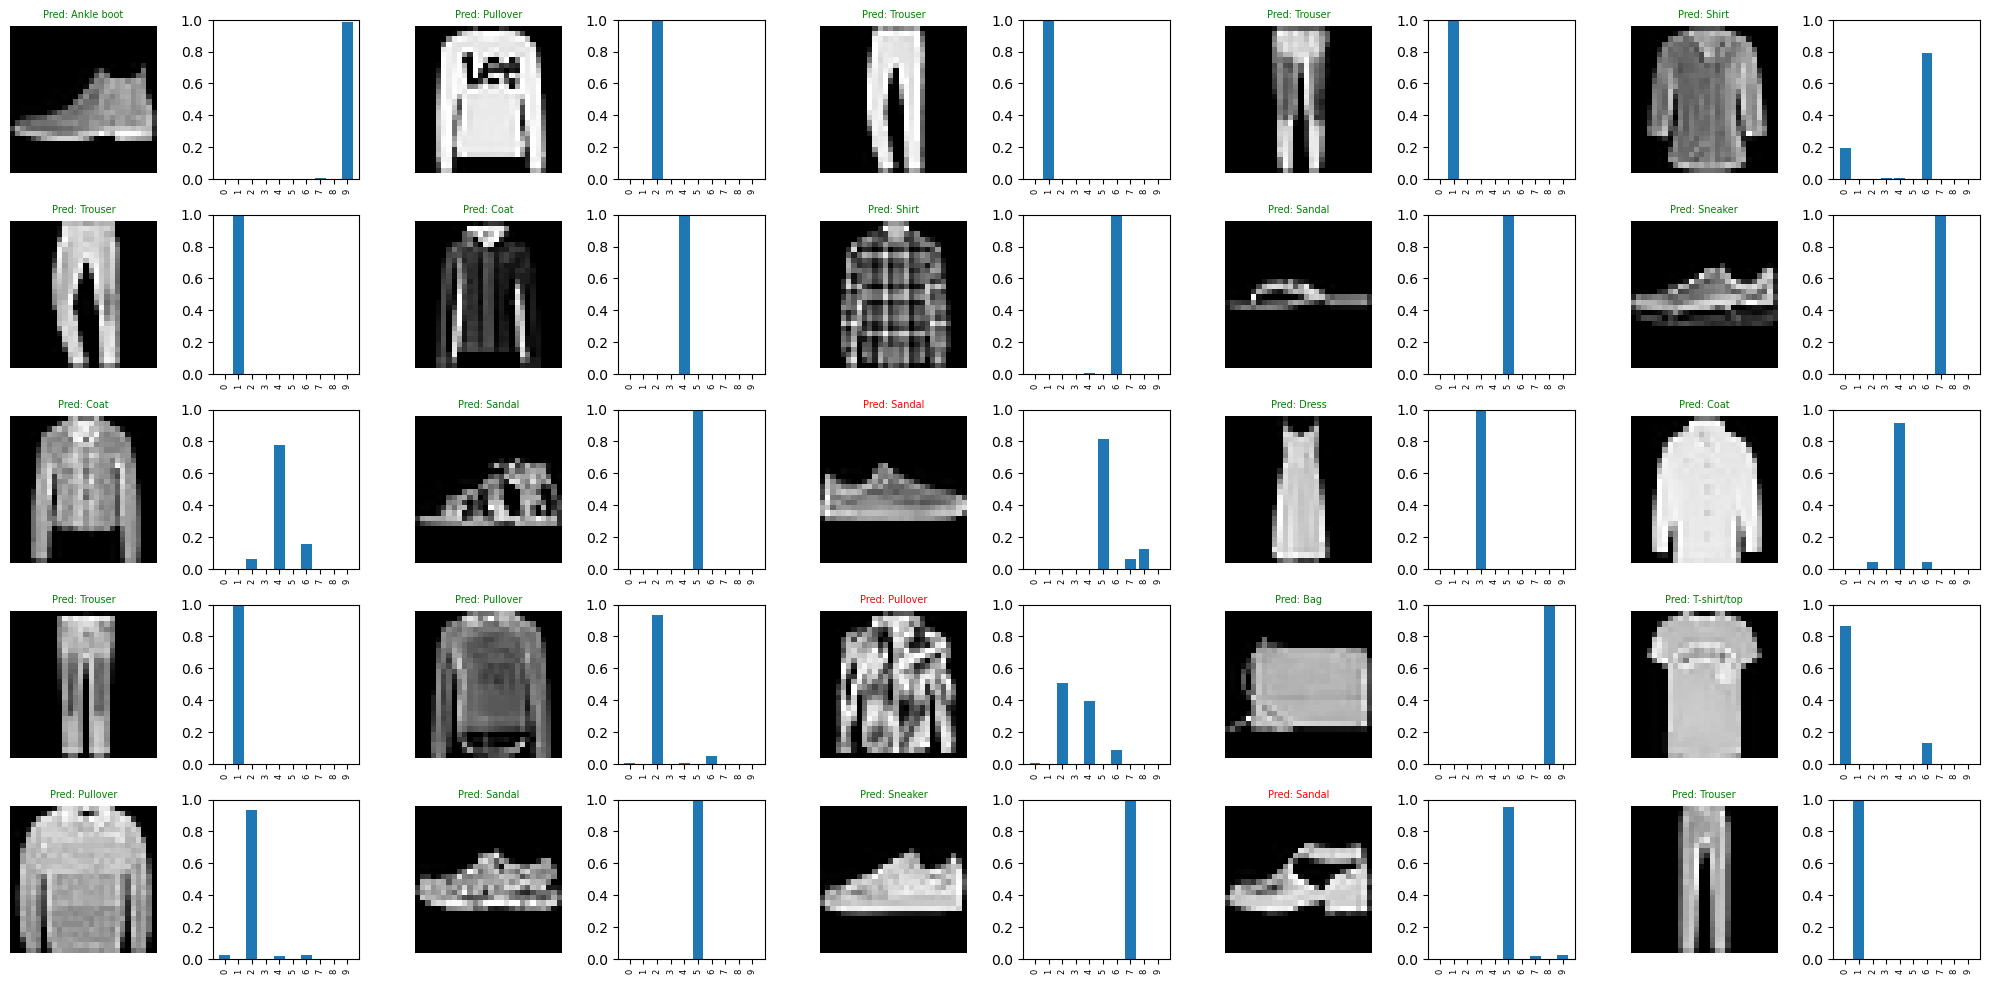

In [25]:
num_rows = 5
num_cols = 5
num_images = num_rows * num_cols

plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))

for i in range(num_images):
    # Left: show the image
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plt.imshow(test_images[i], cmap='gray')
    plt.axis('off')
    
    # Color: green if correct, red if wrong
    color = 'green' if predicted_labels[i] == test_labels[i] else 'red'
    plt.title(f"Pred: {class_names[predicted_labels[i]]}", color=color, fontsize=7)
    
    # Right: show probability bar chart
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plt.bar(range(10), predictions[i])
    plt.xticks(range(10), rotation=90, fontsize=6)
    plt.ylim([0, 1])

plt.tight_layout()
plt.show()